# 02 · Weak (Integral) SINDy

The weakness of vanilla SINDy is the pointwise derivative $\dot X$. **Weak SINDy**
avoids it by multiplying the dynamics by smooth, compactly-supported **test functions**
$\phi_k$ and integrating by parts over many subdomains:

$$\int \phi_k\,\dot X \,dt \;=\; -\int \dot\phi_k\, X\,dt \;=\; \int \phi_k\,\Theta(X)\,dt\;\Xi .$$

The derivative now lands on the *known* test function $\phi_k$, not on noisy data — so
the formulation is **orders of magnitude more robust to noise**. We use `pysindy`'s
`WeakPDELibrary` (configured for an ODE: the only grid dimension is time).

In [1]:
# --- Environment setup (kept INACTIVE on purpose) -------------------------
# Uncomment the next line the first time you run these notebooks to install
# every dependency (pysindy, DaeFinder, cvxpy, ...). Left commented so the
# notebook never reinstalls packages while you teach from it.
# !pip install -r ../requirements.txt

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# Make the shared tutorial package (src/sparse_demos) importable regardless of
# whether the notebook is launched from notebooks/ or the repo root.
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path:
                sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sparse_demos import systems
import pysindy as ps

# Same Lotka-Volterra system, but now with substantial noise.
NOISE = 1.0
tn, Xn = systems.simulate("lotka_volterra", t_span=(0, 20), dt=0.01,
                          noise_std=NOISE, seed=3)
dt = tn[1] - tn[0]

## Vanilla vs. Weak at the same noise level

In [3]:
# Vanilla SINDy on the noisy data
vanilla = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=2),
                   optimizer=ps.STLSQ(threshold=0.05))
vanilla.fit(Xn, t=dt, feature_names=["x", "y"])
print(f"=== Vanilla SINDy  (noise std={NOISE}) ===")
vanilla.print()

# Weak SINDy on the SAME data
weak_lib = ps.WeakPDELibrary(
    function_library=ps.PolynomialLibrary(degree=2, include_bias=True),
    spatiotemporal_grid=tn, is_uniform=True, K=200,
)
weak = ps.SINDy(feature_library=weak_lib, optimizer=ps.STLSQ(threshold=0.05))
weak.fit(Xn, t=dt, feature_names=["x", "y"])
print(f"\n=== Weak SINDy    (noise std={NOISE}) ===")
weak.print()
print("\nTrue:  (x)' = 1.0 x - 0.1 x y     (y)' = -1.5 y + 0.075 x y")

=== Vanilla SINDy  (noise std=1.0) ===
(x)' =  0.171 1 +  0.952 x + -0.102 y + -0.092 x y
(y)' =  0.798 1 + -1.540 y +  0.073 x y

=== Weak SINDy    (noise std=1.0) ===
(x)' = -0.137 1 +  1.001 x + -0.099 x y
(y)' =  0.056 1 + -1.503 y +  0.075 x y

True:  (x)' = 1.0 x - 0.1 x y     (y)' = -1.5 y + 0.075 x y


## A systematic noise sweep

We sweep the noise level and measure the relative coefficient error of each method
against the known ground truth.

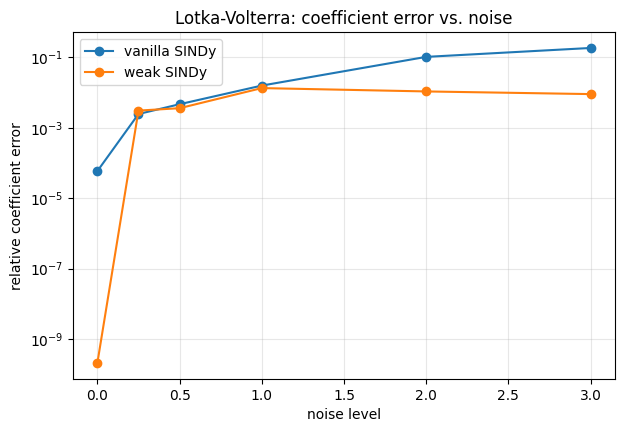

vanilla SINDy ['0.000', '0.002', '0.005', '0.016', '0.104', '0.185']
weak SINDy ['0.000', '0.003', '0.004', '0.013', '0.011', '0.009']


In [8]:
from sparse_demos import metrics, plotting

# Ground-truth coefficient vector for the active terms [x, xy] and [y, xy].
TRUE = {"x": 1.0, "x y": -0.1, "y": -1.5, "x y_y": 0.075}

def coef_dict(model):
    names = model.get_feature_names()
    C = model.coefficients()
    return names, C

def rel_error(model):
    names, C = coef_dict(model)
    # locate library indices for x, y, x y
    idx = {n: names.index(n) for n in ["x", "y", "x y"] if n in names}
    est = np.array([C[0, idx.get("x", 0)], C[0, idx.get("x y", 0)],
                    C[1, idx.get("y", 0)], C[1, idx.get("x y", 0)]])
    true = np.array([1.0, -0.1, -1.5, 0.075])
    return metrics.coef_l2_error(true, est)

noise_levels = [0.0, 0.25, 0.5, 1.0, 2.0, 3.0]
errs = {"vanilla SINDy": [], "weak SINDy": []}
vanilla_models = []
weak_models = []

for nz in noise_levels:
    tt, XX = systems.simulate("lotka_volterra", t_span=(0, 20), dt=0.01,
                              noise_std=nz, seed=7)
    ddt = tt[1] - tt[0]
    v = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=2),
                 optimizer=ps.STLSQ(threshold=0.05))
    v.fit(XX, t=ddt, feature_names=["x", "y"])
    vanilla_models.append(v)
    wl = ps.WeakPDELibrary(function_library=ps.PolynomialLibrary(degree=2, include_bias=True),
                           spatiotemporal_grid=tt, is_uniform=True, K=200)
    w = ps.SINDy(feature_library=wl, optimizer=ps.STLSQ(threshold=0.05))
    w.fit(XX, t=ddt, feature_names=["x", "y"])
    errs["vanilla SINDy"].append(rel_error(v))
    errs["weak SINDy"].append(rel_error(w))
    weak_models.append(w)

plotting.plot_noise_sweep(noise_levels, errs,
                          title="Lotka-Volterra: coefficient error vs. noise")
plt.show()
for k, v in errs.items():
    print(k, ["%.3f" % e for e in v])


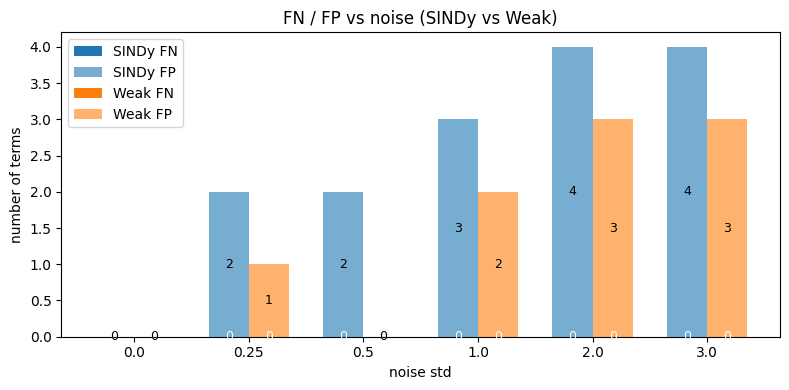

In [9]:
# minimal FP/FN summary & grouped stacked-bar plot (uses existing fitted models)
# Requires: vanilla_models, weak_models, noise_levels (aligned)
def _tokens(s): return set(s.replace("^"," ").replace("*"," ").replace("("," ").replace(")"," ").replace("_"," ").split())
def _true_idxs(names, eq):
    idxs = set()
    for j,n in enumerate(names):
        t = _tokens(n)
        # pure x or pure y
        if eq == 0 and 'x' in t and 'y' not in t and len(t) == 1: idxs.add(j)
        if eq == 1 and 'y' in t and 'x' not in t and len(t) == 1: idxs.add(j)
        # interaction x*y (match any feature containing both tokens)
        if 'x' in t and 'y' in t: idxs.add(j)
        # weak-form may name the interaction 'x y_y' etc. the above handles that.
    return idxs

coef_tol = 1e-8
fp_v, fn_v = [], []
fp_w, fn_w = [], []

for vm, wm in zip(vanilla_models, weak_models):
    # vanilla
    names_v = vm.get_feature_names()
    C_v = np.array(vm.coefficients())
    tot_fp_v = tot_fn_v = 0
    for eq in range(C_v.shape[0]):
        true_idx_v = _true_idxs(names_v, eq)
        pred_idx_v = {j for j,c in enumerate(C_v[eq]) if abs(c) > coef_tol}
        tot_fp_v += len(pred_idx_v - true_idx_v)
        tot_fn_v += len(true_idx_v - pred_idx_v)
    fp_v.append(tot_fp_v); fn_v.append(tot_fn_v)

    # weak
    names_w = wm.get_feature_names()
    C_w = np.array(wm.coefficients())
    tot_fp_w = tot_fn_w = 0
    for eq in range(C_w.shape[0]):
        true_idx_w = _true_idxs(names_w, eq)
        pred_idx_w = {j for j,c in enumerate(C_w[eq]) if abs(c) > coef_tol}
        tot_fp_w += len(pred_idx_w - true_idx_w)
        tot_fn_w += len(true_idx_w - pred_idx_w)
    fp_w.append(tot_fp_w); fn_w.append(tot_fn_w)

# plotting (grouped, stacked)
x = np.arange(len(noise_levels)); width = 0.35
plt.figure(figsize=(8,4))
plt.bar(x - width/2, fn_v, width, label='SINDy FN', color='C0')
plt.bar(x - width/2, fp_v, width, bottom=fn_v, label='SINDy FP', color='C0', alpha=0.6)
plt.bar(x + width/2, fn_w, width, label='Weak FN', color='C1')
plt.bar(x + width/2, fp_w, width, bottom=fn_w, label='Weak FP', color='C1', alpha=0.6)
plt.xticks(x, [str(n) for n in noise_levels])
plt.xlabel('noise std'); plt.ylabel('number of terms'); plt.title('FN / FP vs noise (SINDy vs Weak)')
plt.legend(); plt.tight_layout()
# annotate counts
for i in range(len(x)):
    plt.text(x[i]-width/2, fn_v[i]/2, str(fn_v[i]), ha='center', va='center', color='white', fontsize=9)
    plt.text(x[i]-width/2, fn_v[i]+fp_v[i]/2, str(fp_v[i]), ha='center', va='center', fontsize=9)
    plt.text(x[i]+width/2, fn_w[i]/2, str(fn_w[i]), ha='center', va='center', color='white', fontsize=9)
    plt.text(x[i]+width/2, fn_w[i]+fp_w[i]/2, str(fp_w[i]), ha='center', va='center', fontsize=9)
plt.show()

**Takeaway.** The weak form keeps recovering accurate coefficients well into noise
levels where vanilla SINDy's error explodes — at the cost of choosing test-function
settings (`K`, the number of subdomains). Next: dynamics that are **rational**, which
*no* polynomial library can express. → `03_sindy_pi.ipynb`